In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lava18/google-play-store-apps")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\viren\.cache\kagglehub\datasets\lava18\google-play-store-apps\versions\6


In [7]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import os

path = r"C:\Users\viren\.cache\kagglehub\datasets\lava18\google-play-store-apps\versions\6"

print(os.listdir(path))

['googleplaystore.csv', 'googleplaystore_user_reviews.csv', 'license.txt']


In [9]:
df = pd.read_csv(os.path.join(path, "googleplaystore.csv"))

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [10]:
df.info

<bound method DataFrame.info of                                                      App             Category  \
0         Photo Editor & Candy Camera & Grid & ScrapBook       ART_AND_DESIGN   
1                                    Coloring book moana       ART_AND_DESIGN   
2      U Launcher Lite – FREE Live Cool Themes, Hide ...       ART_AND_DESIGN   
3                                  Sketch - Draw & Paint       ART_AND_DESIGN   
4                  Pixel Draw - Number Art Coloring Book       ART_AND_DESIGN   
...                                                  ...                  ...   
10836                                   Sya9a Maroc - FR               FAMILY   
10837                   Fr. Mike Schmitz Audio Teachings               FAMILY   
10838                             Parkinson Exercices FR              MEDICAL   
10839                      The SCP Foundation DB fr nn5n  BOOKS_AND_REFERENCE   
10840      iHoroscope - 2018 Daily Horoscope & Astrology            LIFESTYLE

In [8]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [10]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)

In [15]:
import pandas as pd
import numpy as np

In [16]:
df.shape

(10358, 13)

In [18]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [19]:
df['Rating'].isnull().sum()

np.int64(1465)

In [22]:
df['Rating'].fillna(df['Rating'].mean()).inplace=True

In [23]:
df.shape

(10358, 13)

In [24]:
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)

df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [25]:
df['Price'] = df['Price'].str.replace('$', '', regex=False)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [26]:
df.info

<bound method DataFrame.info of                                                      App             Category  \
0         Photo Editor & Candy Camera & Grid & ScrapBook       ART_AND_DESIGN   
1                                    Coloring book moana       ART_AND_DESIGN   
2      U Launcher Lite – FREE Live Cool Themes, Hide ...       ART_AND_DESIGN   
3                                  Sketch - Draw & Paint       ART_AND_DESIGN   
4                  Pixel Draw - Number Art Coloring Book       ART_AND_DESIGN   
...                                                  ...                  ...   
10836                                   Sya9a Maroc - FR               FAMILY   
10837                   Fr. Mike Schmitz Audio Teachings               FAMILY   
10838                             Parkinson Exercices FR              MEDICAL   
10839                      The SCP Foundation DB fr nn5n  BOOKS_AND_REFERENCE   
10840      iHoroscope - 2018 Daily Horoscope & Astrology            LIFESTYLE

In [27]:
df.dropna(inplace=True)

In [28]:
df.shape

(10346, 13)

In [29]:
df.to_csv("cleaned_googleplaystore.csv", index=False)

In [1]:
## VISUALIZATIONS

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [12]:
top_categories = df['Category'].value_counts().head(20)

top_categories

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
Name: count, dtype: int64

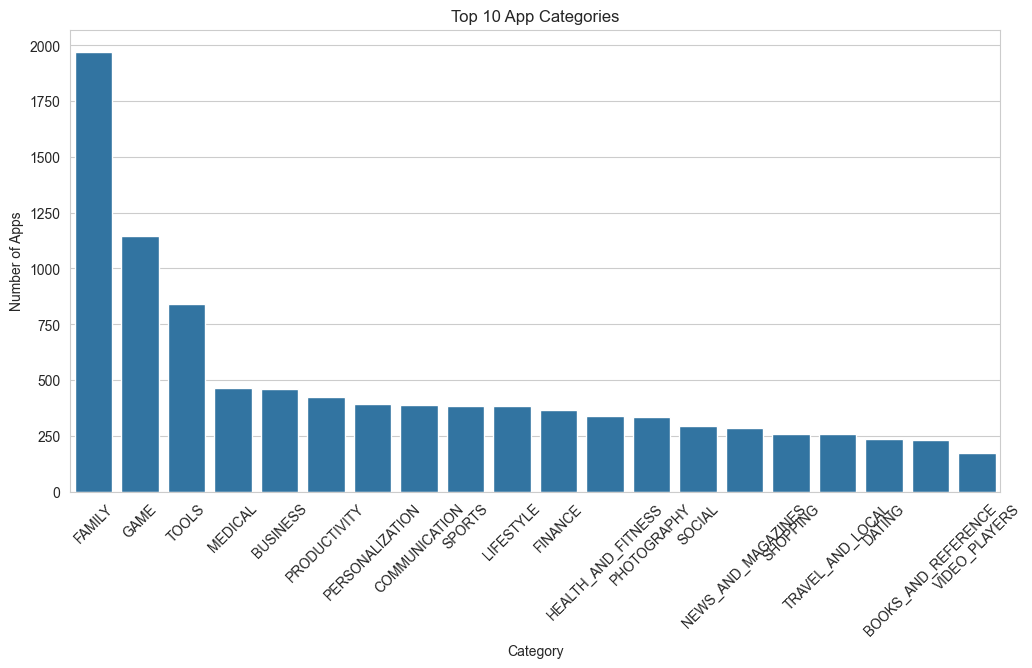

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_categories.index,
    y=top_categories.values
)

plt.title("Top 10 App Categories")
plt.xticks(rotation=45)
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.show()

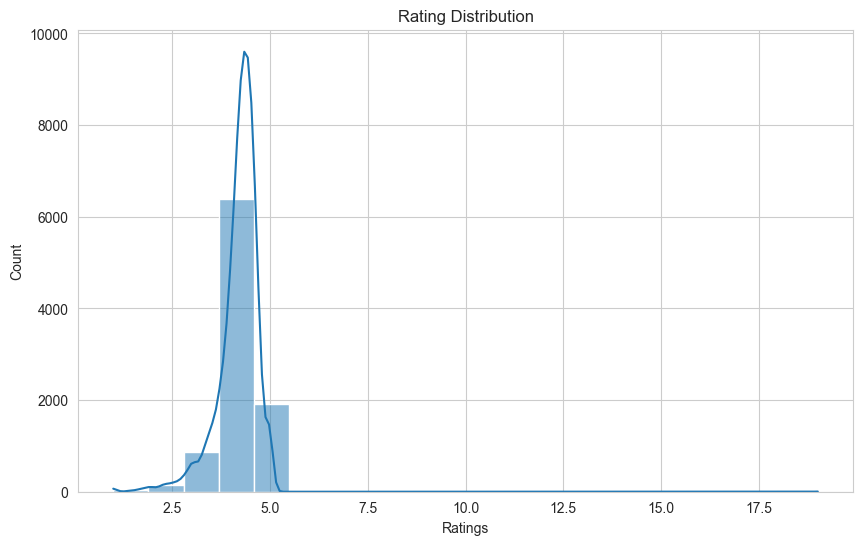

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(df['Rating'], bins=20, kde=True)

plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.show()

In [15]:
# INSTALL ANALYSIS
top_installs = df.sort_values(
    by='Installs',
    ascending=False
).head(10)

top_installs[['App','Installs']]

,App,Installs
10472,Life Made WI-Fi Touchscreen Photo Frame,Free
420,UC Browser - Fast Download Private & Secure,"500,000,000+"
474,LINE: Free Calls & Messages,"500,000,000+"
3767,Flipboard: News For Our Time,"500,000,000+"
3574,Cloud Print,"500,000,000+"
3326,Gboard - the Google Keyboard,"500,000,000+"
431,Viber Messenger,"500,000,000+"
4222,imo free video calls and chat,"500,000,000+"
3235,Google Translate,"500,000,000+"
1842,Candy Crush Saga,"500,000,000+"


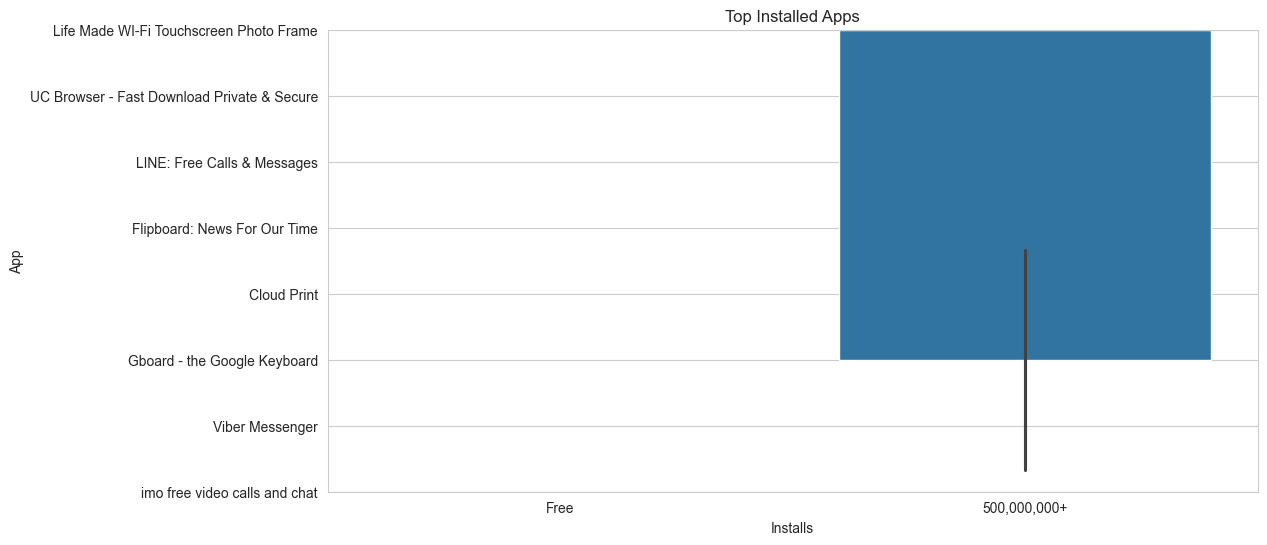

In [16]:
# VISUALIZATION
plt.figure(figsize=(12,6))

sns.barplot(
    x='Installs',
    y='App',
    data=top_installs
)
plt.title('Top Installed Apps')
plt.show()

In [17]:
# FREE & PAID APPS
df['Type'].value_counts()

Type
Free    10039
Paid      800
0           1
Name: count, dtype: int64

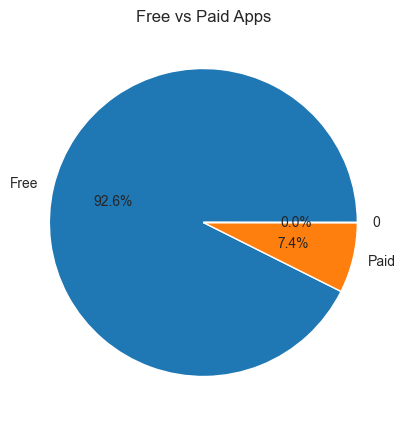

In [20]:
type_counts = df['Type'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%'
)
plt.title('Free vs Paid Apps')
plt.show()

In [21]:
# Category-wise average rating

avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

avg_rating

Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.389032
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.346067
PERSONALIZATION         4.335987
PARENTING               4.300000
GAME                    4.286326
BEAUTY                  4.278571
HEALTH_AND_FITNESS      4.277104
Name: Rating, dtype: float64

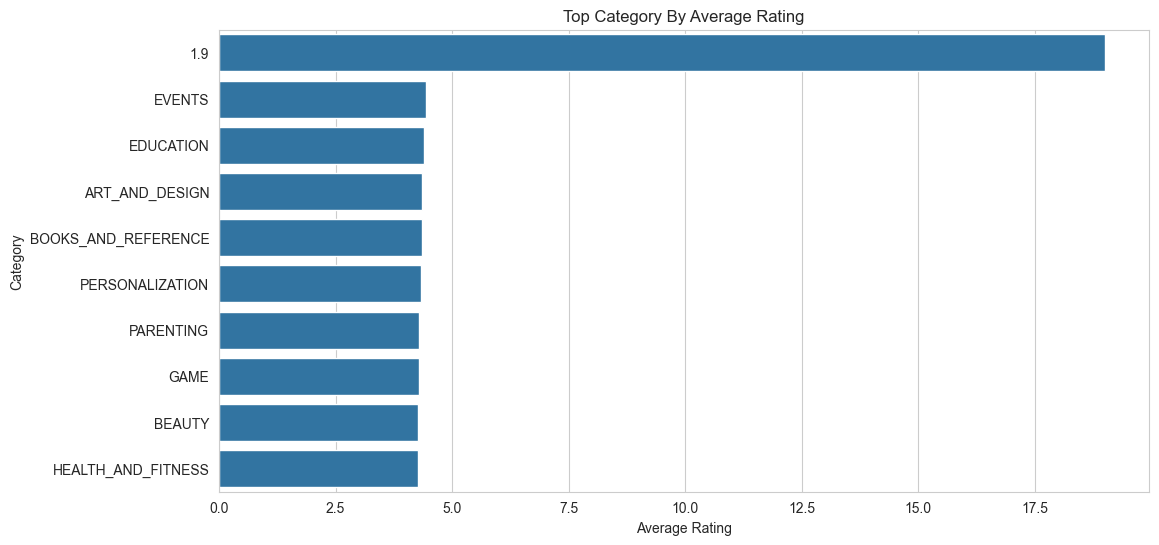

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index,
)
plt.title('Top Category By Average Rating')
plt.xlabel('Average Rating')

plt.show()

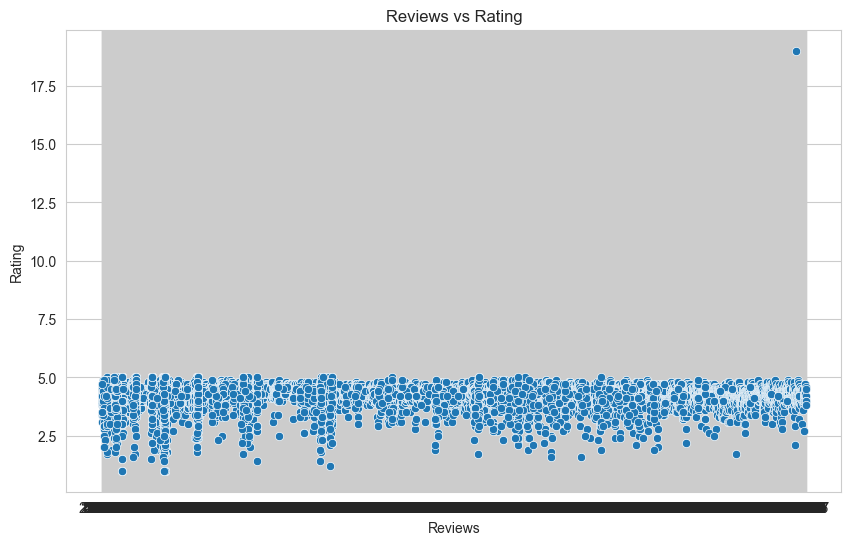

In [25]:
# Reviews vs Rating

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Reviews',
    y='Rating',
    data=df
)

plt.title('Reviews vs Rating')
plt.show()

In [28]:
# CORRELATION HEATMAP

numeric_df = df.select_dtypes(include=['float64','int64'])
corr = numeric_df
corr

,Rating
0,4.1
1,3.9
2,4.7
3,4.5
4,4.3
...,...
10836,4.5
10837,5.0
10838,NaN
10839,4.5


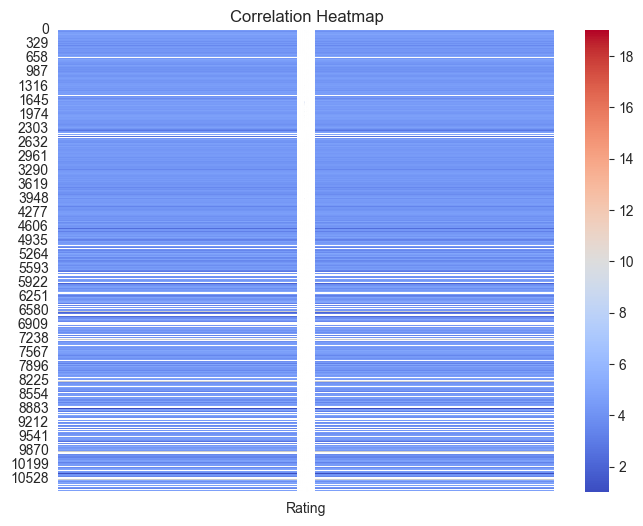

In [30]:
#HEATMAP

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [33]:
# Most Expensive Apps

expensive_apps = df.sort_values(by='Price',ascending=False).head(10)

expensive_apps[['App','Price']]

,App,Price
10472,Life Made WI-Fi Touchscreen Photo Frame,Everyone
0,Photo Editor & Candy Camera & Grid & ScrapBook,0
7079,Filmi Gaane,0
7072,Park Limousine: Realistic Limo Parking Simulator,0
7073,Animal Hunting: Sniper Shooting,0
7074,WISE- MOBILE PORTAL,0
7075,Inwestor mobile,0
7076,BZ Straußenführer,0
7077,Zoosk Dating App: Meet Singles,0
7078,Putzmeister Experts,0


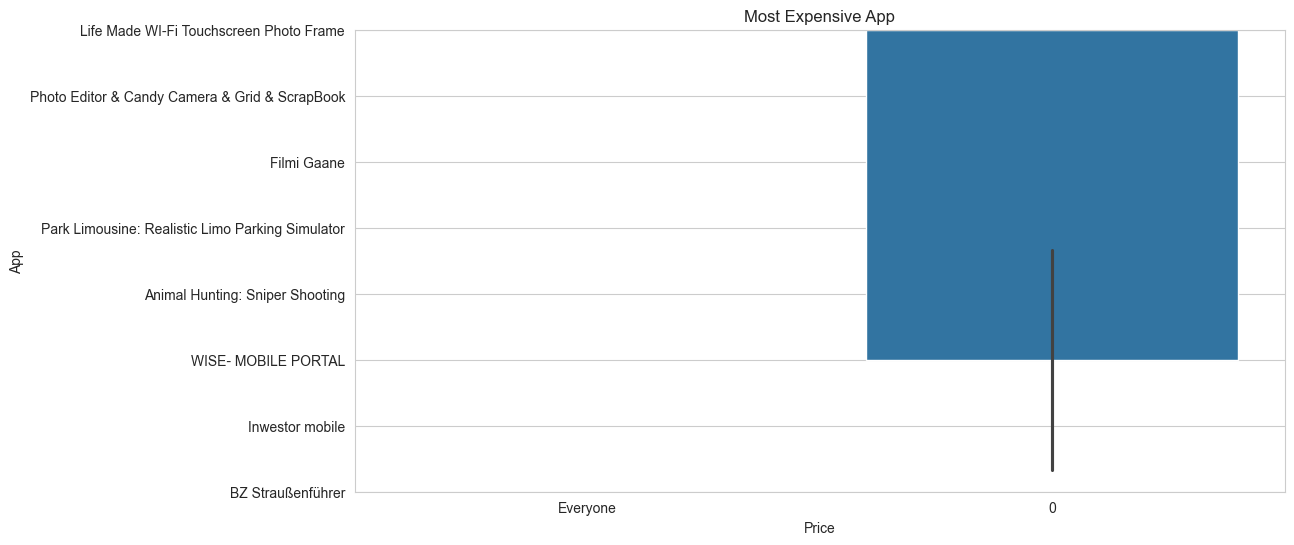

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Price',
    y='App',
    data=expensive_apps
)
plt.title('Most Expensive App')
plt.show()

In [35]:
# APP SIZE ANALYSIS
df['Size'] = df['Size'].str.replace('M', '', regex=False)
df['Size'] = df['Size'].str.replace('k', '', regex=False)

df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

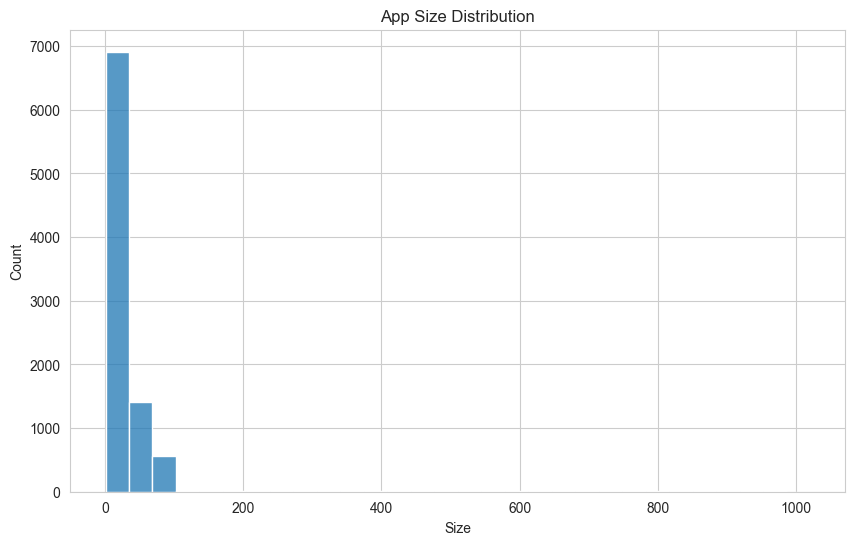

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(df['Size'], bins=30)

plt.title("App Size Distribution")

plt.show()


In [37]:
plt.savefig("chart.png")

<Figure size 640x480 with 0 Axes>